In [1]:
from medtok import available_models, get_model, MODEL_REGISTRY
from medtok.diffusion import create_gaussian_diffusion

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR100
from medmnist import PathMNIST
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
from dataset import MergedMedMNIST
from medmnist import INFO



### Prep Dataset ###
tensor_transforms = transforms.Compose(
    [
        # transforms.Resize((256,256)),
        transforms.ToTensor(),
    ]
)

# train_set = MergedMedMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="train", transform=tensor_transforms, download=False, size=224)
# test_set = MergedMedMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="test", transform=tensor_transforms, download=False, size=224)

train_set = PathMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="train", transform=tensor_transforms, download=False, as_rgb=True, size=224)
test_set = PathMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="test", transform=tensor_transforms, download=False, as_rgb=True, size=224)

# train_set = CIFAR100(root=".", train=True, transform=tensor_transforms, download=True)
# test_set = CIFAR100(root=".", train=False, transform=tensor_transforms, download=True)

### Set Device ###
device = "cuda" if torch.cuda.is_available() else "cpu"

attention mode is flash


In [2]:
def train(model,
          train_set,
          test_set,
          batch_size,
          num_epochs,
          evaluation_iterations):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    
    diffusion = create_gaussian_diffusion(
        steps= 1000,
        learn_sigma= True,
        sigma_small= False,
        noise_schedule= "linear",
        use_kl= False,
        predict_xstart= False,
        rescale_timesteps= False,
        rescale_learned_sigmas= False,
        timestep_respacing= ""
    )

    diffusion_eval = create_gaussian_diffusion(
        steps= 1000,
        learn_sigma= True,
        sigma_small= False,
        noise_schedule= "linear",
        use_kl= False,
        predict_xstart= False,
        rescale_timesteps= False,
        rescale_learned_sigmas= False,
        timestep_respacing= "64"
    )

    train_losses = []
    evaluation_losses = []

    steps_per_epoch = len(trainloader)
    total_steps = steps_per_epoch * num_epochs
    step_counter = 0
    train_loss_running = []
    evaluation_loss_running = []

    with tqdm(total=num_epochs, desc="Epochs") as epoch_bar:
        for epoch in range(num_epochs):
            model.train()
            with tqdm(total=steps_per_epoch, desc=f"Epoch {epoch+1}/{num_epochs} | loss: N/A", leave=False) as pbar:
                for images, labels in trainloader:
                    
                    images, labels = images.to(device), labels.squeeze(1).to(device)
                    cond = dict(y=labels)

                    t = torch.randint(0, diffusion.num_timesteps, (images.shape[0],), device=images.device)
                    z = model.vae_encode(images)
                    
                    terms = diffusion.training_losses(model, z, t, model_kwargs=cond)
                    loss = terms["loss"].mean()

                    # Update tqdm description with current loss value
                    pbar.set_description(f"Epoch {epoch+1}/{num_epochs} | loss: {loss.item():.4f}")

                    train_loss_running.append(loss.item())

                    loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()

                    step_counter += 1
                    pbar.update(1)

                    # if step_counter % 10 == 0:
                    #     break

                    # Evaluate every evaluation_iterations global step
                    if step_counter % evaluation_iterations == 0:
                        model.eval()
                        evaluation_loss_running.clear()
                        example_shown = False
                        with torch.no_grad():
                            sample = diffusion_eval.p_sample_loop(model, z.shape, clip_denoised=True, progress=True, model_kwargs=cond, temperature=1.0)
                            out = model.vae_decode(sample)
                        # INSERT_YOUR_CODE
                        import matplotlib.pyplot as plt

                        # Assume 'out' has shape (batch, channels, height, width) or (batch, height, width)
                        to_show = out[0].detach().cpu().numpy()
                        if to_show.ndim == 3 and to_show.shape[0] in [1, 3]:
                            # (C,H,W) format, move channel last if necessary
                            to_show = np.transpose(to_show, (1, 2, 0))
                        elif to_show.ndim == 2:
                            pass  # Already H x W

                        # Clamp to [0,1] for display
                        plt.figure()
                        plt.imshow(np.clip(to_show, 0, 1), cmap=None if to_show.ndim == 3 else "gray")
                        plt.axis('off')
                        plt.show()


                        train_loss_val = np.mean(train_loss_running) if train_loss_running else 0.0
                        evaluation_loss_val = np.mean(evaluation_loss_running) if evaluation_loss_running else 0.0
                        train_losses.append(train_loss_val)
                        evaluation_losses.append(evaluation_loss_val)
                        train_loss_running = []
                        model.train()
            # if step_counter % 10 == 0:
            #     break
            epoch_bar.update(1)
            

    print("Final Training Loss", train_losses[-1] if train_losses else "No log")
    print("Final Evaluation Loss", evaluation_losses[-1] if evaluation_losses else "No log")

    return model, train_losses, evaluation_losses

('continuous.aekl.f16_d16', 'continuous.aekl.f16_d32', 'continuous.aekl.f16_d64', 'continuous.aekl.f16_d8', 'continuous.aekl.f32_d64', 'continuous.aekl.f4_d16', 'continuous.aekl.f4_d3', 'continuous.aekl.f4_d32', 'continuous.aekl.f4_d8', 'continuous.aekl.f8_d16', 'continuous.aekl.f8_d32', 'continuous.aekl.f8_d4', 'continuous.aekl.f8_d8', 'continuous.maisi.f4_d3', 'continuous.medvae.f8_d16', 'continuous.medvae.f8_d32', 'continuous.vavae.f16_d16_dinov2', 'continuous.vavae.f16_d16_mae', 'continuous.vavae.f16_d32_dinov2', 'continuous.vavae.f16_d32_mae', 'continuous.vavae.f16_d64_dinov2', 'continuous.vavae.f16_d64_mae', 'continuous.vavae.f8_d16_dinov2', 'continuous.vavae.f8_d32_dinov2', 'discrete.bsq.f16_d8_b14', 'discrete.bsq.f4_d3_b13', 'discrete.bsq.f8_d4_b14', 'discrete.fsq.f16_d256_e10', 'discrete.fsq.f16_d256_e12', 'discrete.fsq.f16_d256_e14', 'discrete.fsq.f16_d256_e16', 'discrete.fsq.f16_d256_e8', 'discrete.fsq.f16_d8_l16384', 'discrete.fsq.f4_d3_l8192', 'discrete.fsq.f8_d4_l16384', 

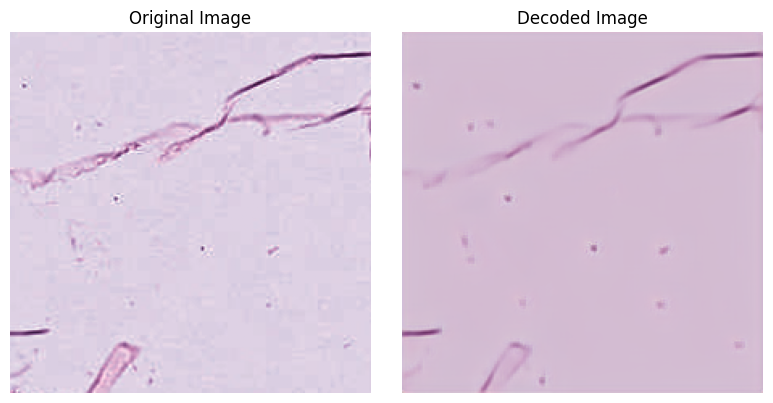

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | loss: N/A:   0%|          | 0/11250 [00:00<?, ?it/s]

AssertionError: model_output.shape: torch.Size([]), x_t.shape: torch.Size([8, 3, 56, 56])

In [3]:
all_models = available_models()
print(all_models)
from medtok.modules.wrapper import GenWrapper


tokenizer = get_model("continuous.aekl.f4_d3", img_size=224, ckpt_path="ckpt.1.pt")
# test the tokenizer 
image = train_set[0][0].unsqueeze(0)
print(image.shape)
decoded = tokenizer.decode(tokenizer.encode(image).mode())
# INSERT_YOUR_CODE

import matplotlib.pyplot as plt

# Visualize the original image
orig_img = image.cpu().detach().squeeze()
if orig_img.ndim == 3:  # (C, H, W)
    if orig_img.shape[0] == 1:
        orig_to_show = orig_img.squeeze(0).numpy() # (H, W) for grayscale
        orig_cmap = "gray"
    else:
        orig_to_show = orig_img.permute(1, 2, 0).numpy() # (H, W, C) for RGB
        orig_cmap = None
else:
    orig_to_show = orig_img.numpy()
    orig_cmap = "gray"

# Visualize the decoded image
decoded_img = decoded
if isinstance(decoded, torch.Tensor):
    decoded_img = decoded.cpu().detach().squeeze()
if decoded_img.ndim == 3:
    if decoded_img.shape[0] == 1:
        dec_to_show = decoded_img.squeeze(0).numpy()
        dec_cmap = "gray"
    else:
        dec_to_show = decoded_img.permute(1, 2, 0).numpy()
        dec_cmap = None
else:
    dec_to_show = decoded_img.numpy()
    dec_cmap = "gray"

plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(orig_to_show, cmap=orig_cmap)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dec_to_show, cmap=dec_cmap)
plt.title("Decoded Image")
plt.axis("off")
plt.tight_layout()
plt.show()



generator = get_model("mar.b", img_size=224, vae_stride=4 , vae_embed_dim=3)
wrapper = GenWrapper(generator, tokenizer)

linear_ae, train_losses, evaluation_losses = train(wrapper,
                                                    train_set=train_set,
                                                    test_set=test_set,
                                                    batch_size=8,
                                                    num_epochs=10,
                                                    evaluation_iterations=2000)

In [ ]:
generated_index = 150
image, label = test_set[generated_index]

# Add batch dimension, move to device
image = image.unsqueeze(0).to(device)

# Forward pass
recon, _ = f4(image)

# Move to CPU, remove batch dim → shape: (C, H, W)
recon = recon.cpu().detach().squeeze()

# Convert to H×W×C (RGB) or H×W (grayscale)
if recon.ndim == 3:                 # C,H,W
    if recon.shape[0] == 1:         # grayscale
        recon = recon.squeeze(0)    # → H,W
        cmap = "gray"
    else:                           # RGB
        recon = recon.permute(1, 2, 0).numpy()
        cmap = None
else:
    cmap = "gray"

plt.imshow(recon, cmap=cmap)
plt.title("RVQVAE")
plt.axis("off")
plt.show()